In [1]:
from kan import *
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
kan_model = KAN(width=[2,5,1], grid=3, k=3, seed=42, device=device)
mpkan_model = MPKAN(width=[2,5,1], grid=3, k=3, seed=42, device=device)

cuda
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0


Create dataset

In [2]:
from kan.utils import create_dataset
# create dataset f(x,y) = exp(sin(pi*x)+y^2)
f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
dataset = create_dataset(f, n_var=2, train_num=100000, test_num=100000, device=device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([100000, 2]), torch.Size([100000, 1]))

Plot KAN at initialization

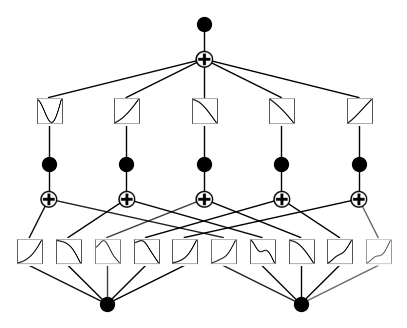

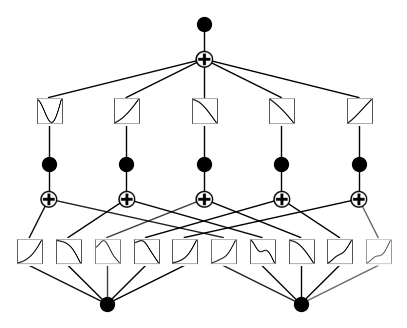

In [3]:
# plot KAN at initialization
kan_model(dataset['train_input']);
kan_model.plot()

# plot MPKAN at initialization
mpkan_model(dataset['train_input']);
mpkan_model.plot()

Train KAN with sparsity regularization

In [4]:
# train the kan_model
kan_model.fit(dataset, opt="Adam", steps=50, lamb=0.001, profile=True)

| train_loss: 2.34e+00 | test_loss: 3.18e+00 | reg: 9.07e+00 | :   2%| | 1/50 [00:00<00:42,  1.15it/STAGE:2025-04-18 19:57:56 117601:117601 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
| train_loss: 1.45e+00 | test_loss: 1.59e+00 | reg: 2.13e+01 | :   8%| | 4/50 [00:01<00:13,  3.45it/STAGE:2025-04-18 19:57:56 117601:117601 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2025-04-18 19:57:56 117601:117601 ActivityProfilerController.cpp:324] Completed Stage: Post Processing
| train_loss: 1.79e-01 | test_loss: 1.42e-01 | reg: 3.98e+01 | : 100%|█| 50/50 [00:12<00:00,  4.03it


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                   volta_dgemm_64x64_nt         0.00%       0.000us         0.00%       0.000us       0.000us     519.834ms        74.53%     519.834ms     129.958ms           0 b           0 b           0 b           0 

{'train_loss': [array(2.34057692),
  array(3.18620274),
  array(1.8841519),
  array(1.44881341),
  array(1.60189822),
  array(1.26802524),
  array(3.2161566),
  array(1.59802416),
  array(1.91701751),
  array(1.85773639),
  array(1.19772879),
  array(2.05275998),
  array(1.29500996),
  array(1.58616108),
  array(1.15638846),
  array(1.95114648),
  array(1.76145379),
  array(0.91899888),
  array(0.94173542),
  array(1.11809461),
  array(0.84526598),
  array(0.72680532),
  array(0.5064596),
  array(0.47644645),
  array(0.52980173),
  array(0.40225758),
  array(0.46609894),
  array(0.44822212),
  array(0.5200582),
  array(0.48417273),
  array(0.50382061),
  array(0.51861871),
  array(0.4951175),
  array(0.3889008),
  array(0.33356052),
  array(0.32428352),
  array(0.2895311),
  array(0.21510752),
  array(0.25573204),
  array(0.21807026),
  array(0.21627974),
  array(0.26102482),
  array(0.25363542),
  array(0.22209023),
  array(0.2049594),
  array(0.226428),
  array(0.20767243),
  array(0

In [5]:
# train the kan_model
mpkan_model.fit(dataset, opt="Adam", steps=50, lamb=0.001, profile=True)

| train_loss: 2.34e+00 | test_loss: 3.18e+00 | reg: 9.07e+00 | :   2%| | 1/50 [00:00<00:13,  3.62it/STAGE:2025-04-18 19:58:08 117601:117601 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
| train_loss: 1.45e+00 | test_loss: 1.59e+00 | reg: 2.13e+01 | :   8%| | 4/50 [00:00<00:09,  4.76it/STAGE:2025-04-18 19:58:09 117601:117601 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2025-04-18 19:58:09 117601:117601 ActivityProfilerController.cpp:324] Completed Stage: Post Processing
| train_loss: 1.79e-01 | test_loss: 1.42e-01 | reg: 3.98e+01 | : 100%|█| 50/50 [00:11<00:00,  4.27it


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                              aten::bmm         0.11%     685.000us         0.19%       1.176ms      56.000us     406.678ms        73.92%     407.373ms      19.399ms           0 b           0 b     137.33 Mb      91.56 M

{'train_loss': [array(2.34057692),
  array(3.18620274),
  array(1.8841519),
  array(1.44881341),
  array(1.60189822),
  array(1.26802524),
  array(3.2161566),
  array(1.59802416),
  array(1.91701751),
  array(1.85773639),
  array(1.19772879),
  array(2.05275998),
  array(1.29500996),
  array(1.58616108),
  array(1.15638846),
  array(1.95114648),
  array(1.76145379),
  array(0.91899888),
  array(0.94173542),
  array(1.11809461),
  array(0.84526598),
  array(0.72680532),
  array(0.5064596),
  array(0.47644645),
  array(0.52980173),
  array(0.40225758),
  array(0.46609894),
  array(0.44822212),
  array(0.5200582),
  array(0.48417273),
  array(0.50382061),
  array(0.51861871),
  array(0.4951175),
  array(0.3889008),
  array(0.33356052),
  array(0.32428352),
  array(0.2895311),
  array(0.21510752),
  array(0.25573204),
  array(0.21807026),
  array(0.21627974),
  array(0.26102482),
  array(0.25363542),
  array(0.22209023),
  array(0.2049594),
  array(0.226428),
  array(0.20767243),
  array(0

Plot trained KAN

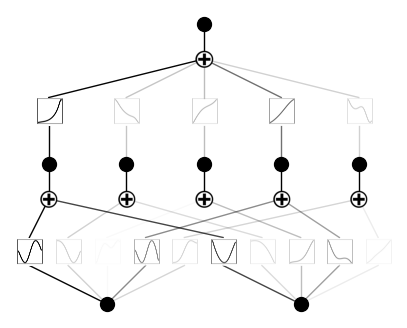

In [6]:
kan_model.plot()

Prune KAN and replot

saving model version 0.2


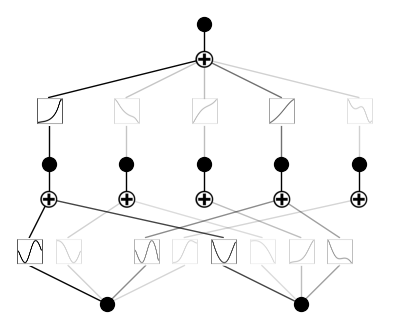

In [7]:
kan_model = kan_model.prune()
kan_model.plot()

Continue training and replot

In [8]:
kan_model.fit(dataset, opt="Adam", steps=50);

| train_loss: 4.03e-01 | test_loss: 3.97e-01 | reg: 9.15e+01 | : 100%|█| 50/50 [00:10<00:00,  4.82it


saving model version 0.3


In [9]:
kan_model = kan_model.refine(10)

saving model version 0.4


In [10]:
kan_model.fit(dataset, opt="Adam", steps=50);

| train_loss: nan | test_loss: nan | reg: nan | : 100%|█████████████| 50/50 [00:13<00:00,  3.67it/s]

saving model version 0.5


Automatically or manually set activation functions to be symbolic

In [11]:
mode = "auto" # "manual"

if mode == "manual":
    # manual mode
    kan_model.fix_symbolic(0,0,0,'sin');
    kan_model.fix_symbolic(0,1,0,'x^2');
    kan_model.fix_symbolic(1,0,0,'exp');
elif mode == "auto":
    # automatic mode
    lib = [
        'x',         # identity
        'x^2', 'x^3', 'x^4',  # polynomials
        'exp',       # exponential
        'log',       # natural log
        'sqrt',      # square root
        'tanh',      # useful for approximating smooth transitions
        'abs',       # absolute value
        'sigmoid',   # approximate CDF if supported
        '1/x',       # reciprocal
        '1/sqrt(x)'  # inverse root for volatility scaling
    ]
    kan_model.auto_symbolic(lib=lib)

OutOfMemoryError: CUDA out of memory. Tried to allocate 7.60 GiB. GPU 0 has a total capacity of 14.57 GiB of which 5.13 GiB is free. Process 55511 has 338.00 MiB memory in use. Process 89181 has 148.00 MiB memory in use. Including non-PyTorch memory, this process has 8.96 GiB memory in use. Of the allocated memory 8.62 GiB is allocated by PyTorch, and 166.58 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Continue training till machine precision

In [ ]:
kan_model.fit(dataset, opt="Adam", steps=50);

| train_loss: 1.20e-13 | test_loss: 1.76e-15 | reg: 0.00e+00 | : 100%|█| 50/50 [00:02<00:00, 19.77it


saving model version 0.7


Obtain the symbolic formula

In [ ]:
from kan.utils import ex_round

ex_round(kan_model.symbolic_formula()[0][0],4)

1.0*exp(1.0*x_2**2 + 1.0*sin(3.1416*x_1))